# Time Series Smoothing & Moving Averages

## Objective
- Understand why smoothing is needed
- Learn Simple Moving Average (SMA)
- Handle odd and even period smoothing
- Visualize smoothing on real data

---

## Why Smoothing is Important?

In real-world time series data, we observe:

- Noise (irregular fluctuations)
- Short-term randomness
- Hidden patterns (trend + seasonality)

### Problem:
Noise makes it difficult to identify:
- Trend
- Seasonal patterns


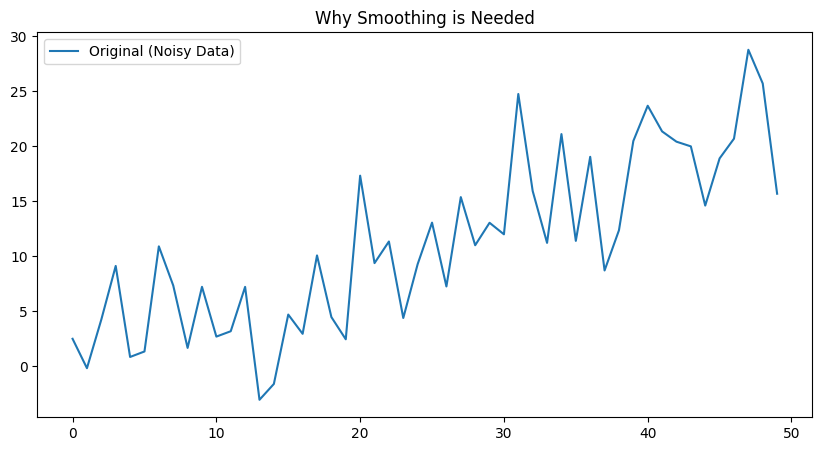

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Create synthetic time series
t = np.arange(50)
trend = 0.5 * t
noise = np.random.normal(0, 5, size=50)

y = trend + noise

plt.figure(figsize=(10,5))
plt.plot(t, y, label="Original (Noisy Data)")
#plt.plot(t, trend, label="True Trend", linewidth=2)
plt.legend()
plt.title("Why Smoothing is Needed")
plt.show()

### Solution:
Apply **Smoothing Techniques**

Smoothing:
- Reduces irregular fluctuations
- Reveals underlying structure
- Helps in better forecasting

---

### Key Idea:
We average nearby values to remove randomness.

---

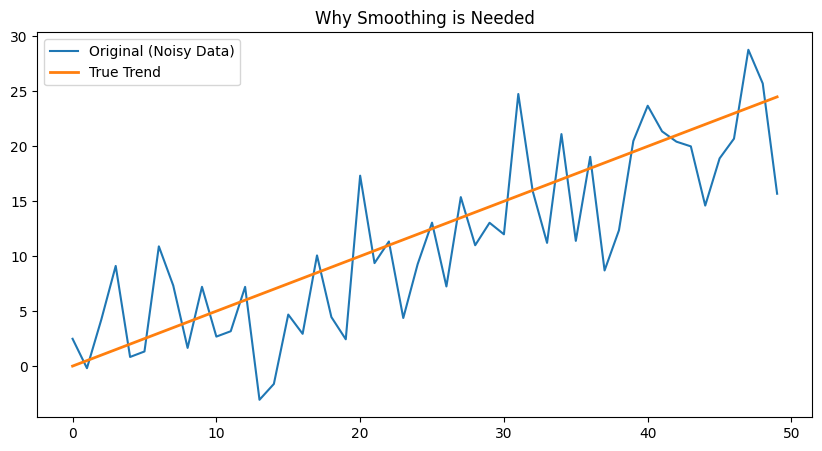

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Create synthetic time series
t = np.arange(50)
trend = 0.5 * t
noise = np.random.normal(0, 5, size=50)

y = trend + noise

plt.figure(figsize=(10,5))
plt.plot(t, y, label="Original (Noisy Data)")
plt.plot(t, trend, label="True Trend", linewidth=2)
plt.legend()
plt.title("Why Smoothing is Needed")
plt.show()

## What is Smoothing?

##### Smoothing techniques:
- Reduce short-term fluctuations
- Highlight long-term patterns


### Why smoothing works?
##### *Noise fluctuates randomly*, so when we average nearby values, it cancels out. *Trend changes slowly*, so it remains. 


### How it works?
- Replace each value with an average of nearby values

---

### Two Common Methods:
1. Moving Average (MA)
    - Simple Moving Average
    - Weighetd Moving Average
2. Exponential Smoothing

## Simple Moving Average (SMA)

The Moving Average is the simplest smoothing method.

### Definition:
Each data point is replaced by the average of its neighboring values.

---

### Formula (m-period MA):

$$
MA_t = \frac{y_{t-k} + \cdots + y_t + \cdots + y_{t+k}}{m}
$$

Where:
- m = window size
- k = (m-1)/2

---

### Key Idea:
- Smooths out noise
- Keeps trend

---

## Moving Average when m is ODD

Example: m = 3, 5, 7

### Key Property:
- There is a clear middle point

---

### Steps:

1. Take first m values
2. Compute average
3. Place it at the middle observation
4. Slide window forward

---

### Example (m = 3):

$$
MA_1 = \frac{y_1 + y_2 + y_3}{3} \rightarrow placed\ at\ y_2
$$

$$
MA_2 = \frac{y_2 + y_3 + y_4}{3} \rightarrow placed\ at\ y_3
$$

---

### Important:
Result is aligned naturally → no adjustment needed

## 3-Point Moving Average (Odd Period)

Consider the following time series:

| Time \(t\) | Value \(Y_t\) |
|---|---:|
| 1 | 20 |
| 2 | 24 |
| 3 | 18 |
| 4 | 22 |
| 5 | 26 |
| 6 | 30 |
| 7 | 28 |
| 8 | 32 |
| 9 | 36 |

We want to compute the **3-point moving average**.

---

### Step 1: Take first 3 values

$$
\frac{20 + 24 + 18}{3} = \frac{62}{3} \approx 20.67
$$

This average is placed at the **middle observation**, i.e. at **time 2**.

---

### Step 2: Move one step forward

$$
\frac{24 + 18 + 22}{3} = \frac{64}{3} \approx 21.33
$$

Placed at **time 3**.

---

### Step 3: Continue

$$
\frac{18 + 22 + 26}{3} = \frac{66}{3} = 22
$$

Placed at **time 4**.

$$
\frac{22 + 26 + 30}{3} = \frac{78}{3} = 26
$$

Placed at **time 5**.

$$
\frac{26 + 30 + 28}{3} = \frac{84}{3} = 28
$$

Placed at **time 6**.

$$
\frac{30 + 28 + 32}{3} = \frac{90}{3} = 30
$$

Placed at **time 7**.

$$
\frac{28 + 32 + 36}{3} = \frac{96}{3} = 32
$$

Placed at **time 8**.

---

### Final Table

| Window Used | Average | Placed At Time |
|---|---:|---:|
| (20, 24, 18) | 20.67 | 2 |
| (24, 18, 22) | 21.33 | 3 |
| (18, 22, 26) | 22.00 | 4 |
| (22, 26, 30) | 26.00 | 5 |
| (26, 30, 28) | 28.00 | 6 |
| (30, 28, 32) | 30.00 | 7 |
| (28, 32, 36) | 32.00 | 8 |

---

### Final 3-Point Moving Average Series

| Time | 3-Point MA |
|---|---:|
| 2 | 20.67 |
| 3 | 21.33 |
| 4 | 22.00 |
| 5 | 26.00 |
| 6 | 28.00 |
| 7 | 30.00 |
| 8 | 32.00 |

---

### Note
For **odd m**, there is a natural center.  
So the moving average is directly placed at the middle observation.

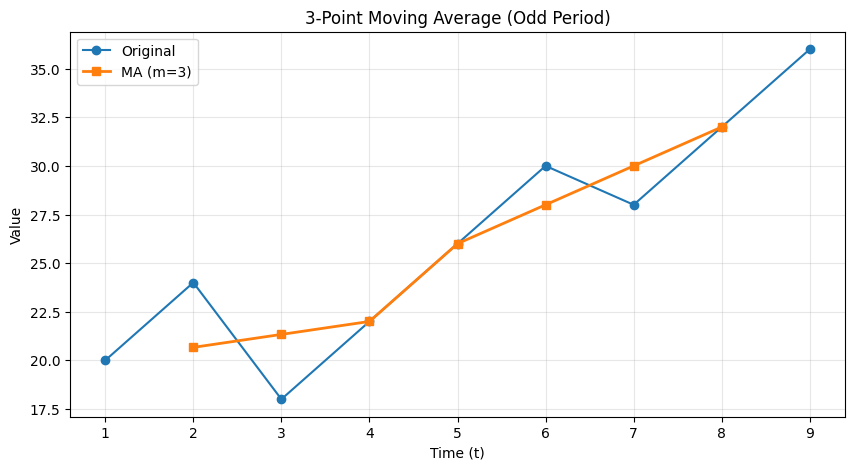

In [6]:
def moving_average(data, m):
    return np.convolve(data, np.ones(m)/m, mode='valid')
data = np.array([20, 24, 18, 22, 26, 30, 28, 32, 36])
ma_3 = moving_average(data, 3)

# X-axis for original data
x_original = np.arange(1, len(data) + 1)

# X-axis for MA (placed at middle → starts at 2)
x_ma = np.arange(2, len(data))  # 2 to 8

plt.figure(figsize=(10,5))
plt.plot(x_original, data, marker='o', label="Original")
plt.plot(x_ma, ma_3, marker='s', label="MA (m=3)", linewidth=2)

plt.xlabel("Time (t)")
plt.ylabel("Value")
plt.legend()
plt.title("3-Point Moving Average (Odd Period)")
plt.grid(alpha=0.3)

plt.show()

## 4-Point Moving Average (Even Period)

Consider the following time series:

| Time \(t\) | Value \(Y_t\) |
|---|---:|
| 1 | 20 |
| 2 | 24 |
| 3 | 18 |
| 4 | 22 |
| 5 | 26 |
| 6 | 30 |
| 7 | 28 |
| 8 | 32 |
| 9 | 36 |

We want to compute the **4-point moving average**.

---

## Step 1: Compute 4-point Moving Averages

$$
\frac{20 + 24 + 18 + 22}{4} = \frac{84}{4} = 21
$$

Placed between **time 2 and 3**.

---

$$
\frac{24 + 18 + 22 + 26}{4} = \frac{90}{4} = 22.5
$$

Placed between **time 3 and 4**.

---

$$
\frac{18 + 22 + 26 + 30}{4} = \frac{96}{4} = 24
$$

Placed between **time 4 and 5**.

---

$$
\frac{22 + 26 + 30 + 28}{4} = \frac{106}{4} = 26.5
$$

Placed between **time 5 and 6**.

---

$$
\frac{26 + 30 + 28 + 32}{4} = \frac{116}{4} = 29
$$

Placed between **time 6 and 7**.

---

$$
\frac{30 + 28 + 32 + 36}{4} = \frac{126}{4} = 31.5
$$

Placed between **time 7 and 8**.

---

## Step 2: Center the Moving Averages

Since \(m = 4\) (even), there is **no exact center**.  
So we compute **Centered Moving Averages (CMA)**.

---

$$
\frac{21 + 22.5}{2} = 21.75
$$

Placed at **time 3**.

---

$$
\frac{22.5 + 24}{2} = 23.25
$$

Placed at **time 4**.

---

$$
\frac{24 + 26.5}{2} = 25.25
$$

Placed at **time 5**.

---

$$
\frac{26.5 + 29}{2} = 27.75
$$

Placed at **time 6**.

---

$$
\frac{29 + 31.5}{2} = 30.25
$$

Placed at **time 7**.

---

## Final Table

### 4-Point Moving Averages

| Window Used | Average | Position |
|---|---:|---|
| (20, 24, 18, 22) | 21.00 | between 2 & 3 |
| (24, 18, 22, 26) | 22.50 | between 3 & 4 |
| (18, 22, 26, 30) | 24.00 | between 4 & 5 |
| (22, 26, 30, 28) | 26.50 | between 5 & 6 |
| (26, 30, 28, 32) | 29.00 | between 6 & 7 |
| (30, 28, 32, 36) | 31.50 | between 7 & 8 |

---

### Centered Moving Averages

| Pair of MAs | CMA | Placed At Time |
|---|---:|---:|
| (21.00, 22.50) | 21.75 | 3 |
| (22.50, 24.00) | 23.25 | 4 |
| (24.00, 26.50) | 25.25 | 5 |
| (26.50, 29.00) | 27.75 | 6 |
| (29.00, 31.50) | 30.25 | 7 |

---

## Final Centered Moving Average Series

| Time | 4-Point CMA |
|---|---:|
| 3 | 21.75 |
| 4 | 23.25 |
| 5 | 25.25 |
| 6 | 27.75 |
| 7 | 30.25 |

---

### Note
For **even m**, there is no natural center.  
So we first compute moving averages, then **center them** to align with time.

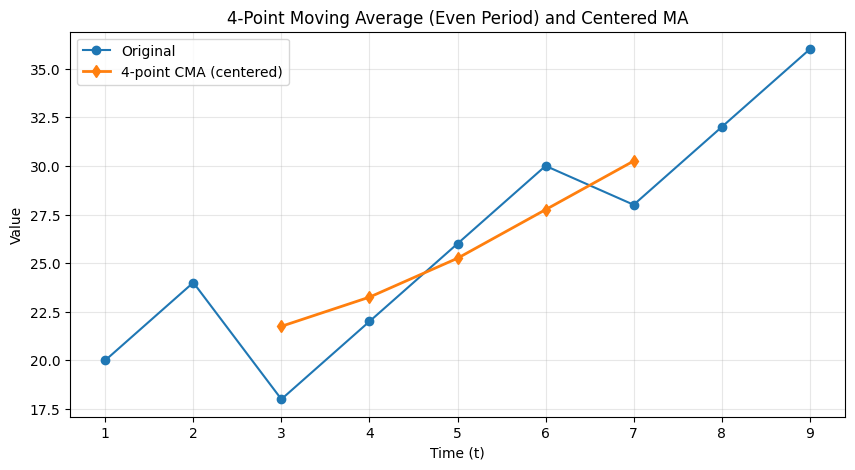

In [7]:
def moving_average(data, m):
    return np.convolve(data, np.ones(m)/m, mode='valid')

# 4-point moving average (even m) with centering
data = np.array([20, 24, 18, 22, 26, 30, 28, 32, 36])

ma_4 = moving_average(data, 4)       # 4-point MA (values between t=2-3 .. t=7-8)
cma = moving_average(ma_4, 2)        # centered MA → aligned at t=3..7

x_orig = np.arange(1, len(data) + 1)
x_cma = np.arange(3, 3 + len(cma))       # centered positions

plt.figure(figsize=(10,5))
plt.plot(x_orig, data, marker='o', label='Original')
plt.plot(x_cma, cma, marker='d', label='4-point CMA (centered)', linewidth=2)

plt.xlabel("Time (t)")
plt.ylabel("Value")
plt.title("4-Point Moving Average (Even Period) and Centered MA")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Key Insight

### Rule:
Moving Average removes seasonal variation if:

$$
m = \text{seasonal period}
$$

---

### Examples:

| Data Type | Seasonal Cycle | m |
|----------|---------------|---|
| Monthly  | 12 months     | 12 |
| Quarterly| 4 quarters    | 4 |
| Weekly   | 7 days        | 7 |

---

### Why?

Because averaging over one full cycle cancels seasonal effects.

---

### Special Case:
If cycle varies: 
- Use average cycle length as m

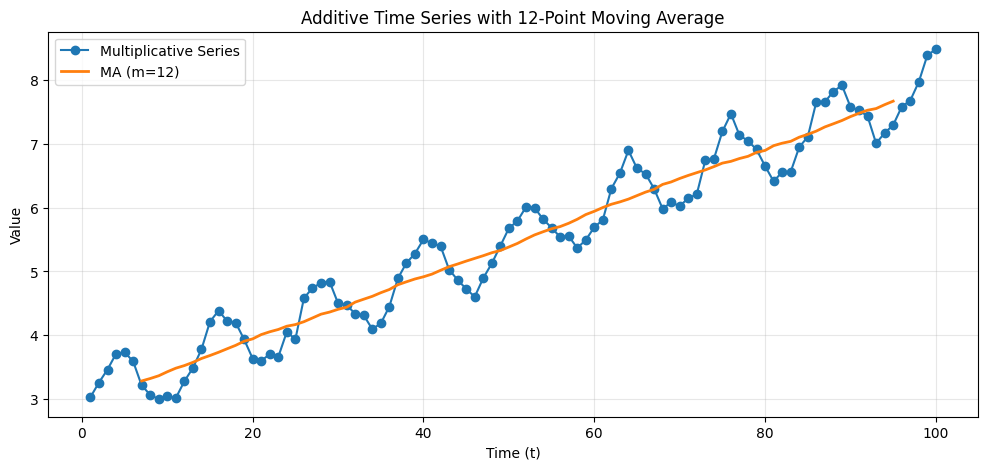

In [8]:
import numpy as np
import matplotlib.pyplot as plt

t = np.arange(100)

# Trend (always positive)
trend = 1 + 0.05 * t

# Seasonal (shifted to be positive)
seasonal = 1 + 0.5 * np.sin(2 * np.pi * t / 12)

# Noise (multiplicative noise around 1)
noise = np.random.normal(1, 0.1, 100)

# Multiplicative model
y = trend + seasonal + noise

# Moving average
ma_12 = moving_average(y, 12)

# X-axis alignment
x_original = np.arange(1, len(y) + 1)
x_ma = np.arange(7, len(ma_12) + 7)

plt.figure(figsize=(12,5))
plt.plot(x_original, y, label="Multiplicative Series", marker='o')
plt.plot(x_ma, ma_12, label="MA (m=12)", linewidth=2)

plt.xlabel("Time (t)")
plt.ylabel("Value")
plt.legend()
plt.title("Additive Time Series with 12-Point Moving Average")
plt.grid(alpha=0.3)
plt.show()

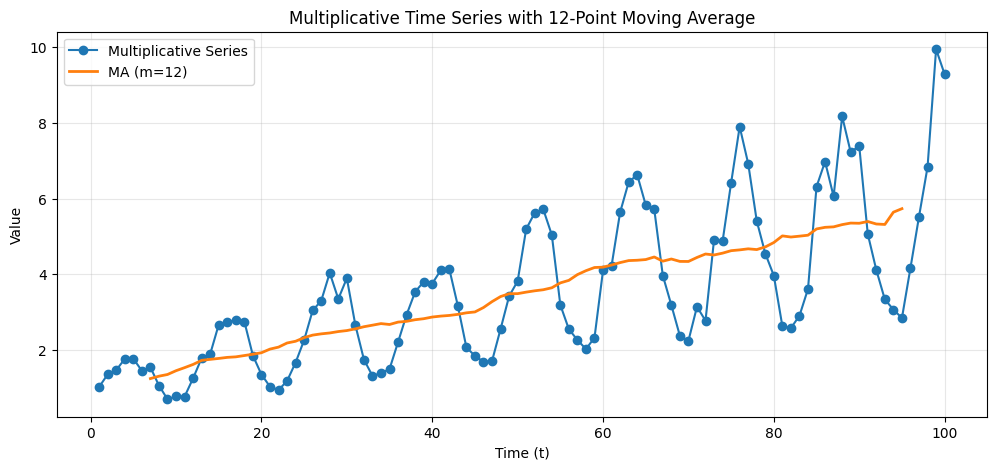

In [9]:
import numpy as np
import matplotlib.pyplot as plt

t = np.arange(100)

# Trend (always positive)
trend = 1 + 0.05 * t

# Seasonal (shifted to be positive)
seasonal = 1 + 0.5 * np.sin(2 * np.pi * t / 12)

# Noise (multiplicative noise around 1)
noise = np.random.normal(1, 0.1, 100)

# Multiplicative model
y = trend * seasonal * noise

# Moving average
ma_12 = moving_average(y, 12)

# X-axis alignment
x_original = np.arange(1, len(y) + 1)
x_ma = np.arange(7, len(ma_12) + 7)

plt.figure(figsize=(12,5))
plt.plot(x_original, y, label="Multiplicative Series", marker='o')
plt.plot(x_ma, ma_12, label="MA (m=12)", linewidth=2)

plt.xlabel("Time (t)")
plt.ylabel("Value")
plt.legend()
plt.title("Multiplicative Time Series with 12-Point Moving Average")
plt.grid(alpha=0.3)
plt.show()

## Summary

### Smoothing:
- Removes noise
- Reveals trend

---

### Moving Average:
- Average of neighboring values
- Reduces irregular fluctuations

---

### Odd m:
- Has center
- Direct placement

---

### Even m:
- No center
- Use centered moving average

---

### Key Rule:
Choose m = seasonal cycle

## <u>Why do we need Weighted Moving Average?</u>

In Simple Moving Average (SMA):
- All observations are given **equal importance**

Problem:
- Recent data may be **more relevant**
- Older data may be **less useful**

---

### Example

Suppose:
- Last month’s sales = very important
- Data from 6 months ago = less important

**SMA treats both equally**

---

### Solution

 Assign **different weights**

This leads to:

### Weighted Moving Average (WMA)

## <u>Definition of Weighted Moving Average</u>

If weights are:

$$
w_1, w_2, \dots, w_m
$$

and observations are:

$$
y_1, y_2, \dots, y_m
$$

Then:

$$
WMA = \frac{w_1 y_1 + w_2 y_2 + \cdots + w_m y_m}{w_1 + w_2 + \cdots + w_m}
$$

---

## Conditions

$$(w_i \ge 0)$$
- Usually: Recent observations get **higher weights**

---

## Key Idea

- Not all data points are equally important
- More importance to **recent values**

## Numerical Example
Consider:

| Time | Value |
|---|---:|
| 1 | 20 |
| 2 | 24 |
| 3 | 18 |
| 4 | 22 |
| 5 | 26 |
| 6 | 30 |
| 7 | 28 |
| 8 | 32 |
| 9 | 36 |

Weights (more importance to recent):
### **$w = [1, 2, 3]$**

---

### Step 1: First Window

$$
WMA_1 = \frac{1(20) + 2(24) + 3(18)}{1 + 2 + 3}
$$

$$
= \frac{20 + 48 + 54}{6} = \frac{122}{6} \approx 20.33
$$

Placed at **time 2**

---

### Step 2: Move Forward

$$
WMA_2 = \frac{1(24) + 2(18) + 3(22)}{6}
$$

$$
= \frac{24 + 36 + 66}{6} = \frac{126}{6} = 21
$$

Placed at **time 3**

---

### Step 3: Continue

$$
WMA_3 = \frac{1(18) + 2(22) + 3(26)}{6}
$$

$$
= \frac{18 + 44 + 78}{6} = \frac{140}{6} \approx 23.33
$$

Placed at **time 4**

---

$$
WMA_4 = \frac{1(22) + 2(26) + 3(30)}{6}
$$

$$
= \frac{22 + 52 + 90}{6} = \frac{164}{6} \approx 27.33
$$

Placed at **time 5**

---

$$
WMA_5 = \frac{1(26) + 2(30) + 3(28)}{6}
$$

$$
= \frac{26 + 60 + 84}{6} = \frac{170}{6} \approx 28.33
$$

Placed at **time 6**

---

$$
WMA_6 = \frac{1(30) + 2(28) + 3(32)}{6}
$$

$$
= \frac{30 + 56 + 96}{6} = \frac{182}{6} \approx 30.33
$$

Placed at **time 7**

---

$$
WMA_7 = \frac{1(28) + 2(32) + 3(36)}{6}
$$

$$
= \frac{28 + 64 + 108}{6} = \frac{200}{6} \approx 33.33
$$

Placed at **time 8**

---

### Final Table

| Window Used | WMA | Placed At Time |
|---|---:|---:|
| (20, 24, 18) | 20.33 | 2 |
| (24, 18, 22) | 21.00 | 3 |
| (18, 22, 26) | 23.33 | 4 |
| (22, 26, 30) | 27.33 | 5 |
| (26, 30, 28) | 28.33 | 6 |
| (30, 28, 32) | 30.33 | 7 |
| (28, 32, 36) | 33.33 | 8 |

---

### Insight

- More weight is given to recent values
- Output reacts faster to changes than SMA

#### This is the key advantage of WMA over SMA

In [10]:
data = np.array([10, 20, 30])
weights = np.array([1, 2, 3])

wma = np.sum(data * weights) / np.sum(weights)

print("Weighted Moving Average:", wma)

Weighted Moving Average: 23.333333333333332


## Moving Weighted Average (Time Series)

Just like SMA:
- We slide the window

But instead of simple average:
- we compute **weighted average**

---

### Steps

1. Select m observations
2. Assign weights
3. Compute weighted average
4. Move window forward

---

- Same procedure as SMA, only formula changes

In [11]:
def weighted_moving_average(data, weights):
    m = len(weights)
    wma = []
    
    for i in range(len(data) - m + 1):
        window = data[i:i+m]
        value = np.sum(window * weights) / np.sum(weights)
        wma.append(value)
    
    return np.array(wma)

In [12]:
data = np.array([20, 24, 18, 22, 26, 30, 28, 32, 36])

# More weight to recent values
weights = np.array([1, 2, 3])  # increasing weights

wma_3 = weighted_moving_average(data, weights)
wma_3 = np.round(wma_3, 2)

print("Original Data:", data)
print(wma_3)

Original Data: [20 24 18 22 26 30 28 32 36]
[20.33 21.   23.33 27.33 28.33 30.33 33.33]


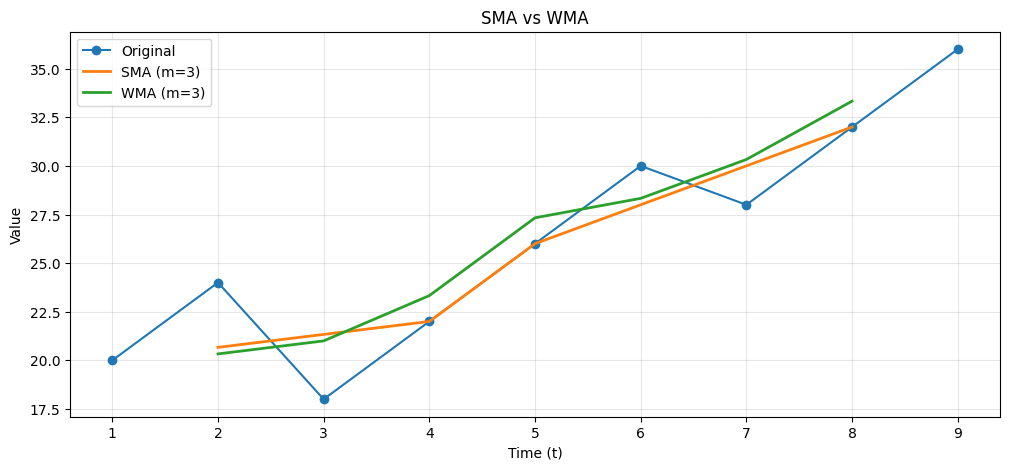

In [13]:
import matplotlib.pyplot as plt

# SMA
sma_3 = moving_average(data, 3)

# X-axis
x_original = np.arange(1, len(data) + 1)
x_ma = np.arange(2, len(data))

plt.figure(figsize=(12,5))

plt.plot(x_original, data, marker='o', label="Original")
plt.plot(x_ma, sma_3, label="SMA (m=3)", linewidth=2)
plt.plot(x_ma, wma_3, label="WMA (m=3)", linewidth=2)

plt.xlabel("Time (t)")
plt.ylabel("Value")
plt.legend()
plt.title("SMA vs WMA")
plt.grid(alpha=0.3)

plt.show()

## Key Insights

### SMA
- Equal weights
- Smooth but slow to react

---

### WMA
- Unequal weights
- More responsive to recent changes

---

### Important

- WMA reacts faster to trend changes than SMA

---

### Trade-off

| Method | Advantage | Disadvantage |
|-------|----------|-------------|
| SMA | Stable | Slow |
| WMA | Responsive | More sensitive to noise |

## <u>What is Exponential Smoothing?</u>

Exponential smoothing is a very popular forecasting method in business because it is:

- simple
- easy to automate
- inexpensive
- effective in many practical situations

---

### Main Idea

In moving average:
- we average only the **most recent $m$ observations**

In exponential smoothing:
- we take a weighted average of **all past observations**
- recent observations get **more weight**
- older observations get **less weight**
- but older observations are **not completely ignored**

---

### Why is it called exponential smoothing?

Because the weights assigned to past observations decrease **exponentially** as we move backward in time.

## When is Simple Exponential Smoothing Used?

Simple exponential smoothing is suitable when the time series has:

- no trend
- no seasonality
- approximately constant level over time

---

### Assumption

The series fluctuates around a constant local mean.

---

### Important Note

If the original series has trend or seasonality:
- first remove trend and/or seasonality
- then apply exponential smoothing to the residual or de-trended series

## Formula of Exponential Smoothing

If $$ y_1, y_2, \dots, y_t $$ are the observations, then the smoothed value at time $$t$$ is:

$$
y_t' = \alpha y_t + \alpha(1-\alpha)y_{t-1} + \alpha(1-\alpha)^2 y_{t-2} + \cdots
$$

This shows that:
- the most recent value gets the highest weight
- older values get smaller and smaller weights

---

### Recursive Form

A more convenient form is:

$$
y_t' = \alpha y_t + (1-\alpha)y_{t-1}'
$$

where:
- $y_t'$ = smoothed value at time $t$
- $\alpha$ = smoothing constant
- $0 < \alpha < 1$

---

### Meaning of $\alpha$

- larger $\alpha$ → more weight on recent observation
- smaller $\alpha$ → smoother series, slower response

## Initial Smoothed Value

To start the method, we take:

$$
y_1' = y_1
$$

That is, the first smoothed value is taken as the first observation itself.

---

Then the next values are computed recursively:

$$
y_2' = \alpha y_2 + (1-\alpha)y_1'
$$

$$
y_3' = \alpha y_3 + (1-\alpha)y_2'
$$

and so on.

## Numerical Example (Board Level)

Consider the following time series:

| Time | Value |
|---|---:|
| 1 | 20 |
| 2 | 24 |
| 3 | 18 |
| 4 | 22 |
| 5 | 26 |
| 6 | 30 |
| 7 | 28 |
| 8 | 32 |
| 9 | 36 |

Let the smoothing constant be:

$$
\alpha = 0.2
$$

We compute the smoothed values step by step.

---

### Step 1: First smoothed value

$$
y_1' = y_1 = 20
$$

---

### Step 2: Second smoothed value

$$
y_2' = 0.2(24) + 0.8(20)
$$

$$
= 4.8 + 16 = 20.80
$$

---

### Step 3: Third smoothed value

$$
y_3' = 0.2(18) + 0.8(20.80)
$$

$$
= 3.6 + 16.64 = 20.24
$$

---

### Step 4: Fourth smoothed value

$$
y_4' = 0.2(22) + 0.8(20.24)
$$

$$
= 4.4 + 16.19 = 20.59
$$

---

### Step 5: Fifth smoothed value

$$
y_5' = 0.2(26) + 0.8(20.59)
$$

$$
= 5.2 + 16.47 = 21.67
$$

---

### Step 6: Sixth smoothed value

$$
y_6' = 0.2(30) + 0.8(21.67)
$$

$$
= 6 + 17.34 = 23.34
$$

---

### Step 7: Seventh smoothed value

$$
y_7' = 0.2(28) + 0.8(23.34)
$$

$$
= 5.6 + 18.67 = 24.27
$$

---

### Step 8: Eighth smoothed value

$$
y_8' = 0.2(32) + 0.8(24.27)
$$

$$
= 6.4 + 19.42 = 25.82
$$

---

### Step 9: Ninth smoothed value

$$
y_9' = 0.2(36) + 0.8(25.82)
$$

$$
= 7.2 + 20.66 = 27.86
$$

## Final Smoothed Series

| Time | Original Value $y_t$ | Smoothed Value $y_t'$ |
|---|---:|---:|
| 1 | 20 | 20.00 |
| 2 | 24 | 20.80 |
| 3 | 18 | 20.24 |
| 4 | 22 | 20.59 |
| 5 | 26 | 21.67 |
| 6 | 30 | 23.34 |
| 7 | 28 | 24.27 |
| 8 | 32 | 25.82 |
| 9 | 36 | 27.86 |

---

### Observation

- The smoothed series is less jumpy than the original series
- It follows the general level of the series
- It reacts gradually rather than abruptly

In [22]:
def exponential_smoothing(data, alpha):
    smoothed = [data[0]]  # first smoothed value
    for t in range(1, len(data)):
        s_t = alpha * data[t] + (1 - alpha) * smoothed[t - 1]
        smoothed.append(s_t)
    
    return np.array(smoothed)

In [24]:
import pandas as pd
data = np.array([20, 24, 18, 22, 26, 30, 28, 32, 36])
alpha = 0.2

es = exponential_smoothing(data, alpha)
es = np.round(es, 2)

df_es = pd.DataFrame({
    "Time": np.arange(1, len(data) + 1),
    "Original Value": data,
    "Smoothed Value": es
})

df_es

,Time,Original Value,Smoothed Value
0,1,20,20.00
1,2,24,20.80
2,3,18,20.24
3,4,22,20.59
4,5,26,21.67
5,6,30,23.34
6,7,28,24.27
7,8,32,25.82
8,9,36,27.85


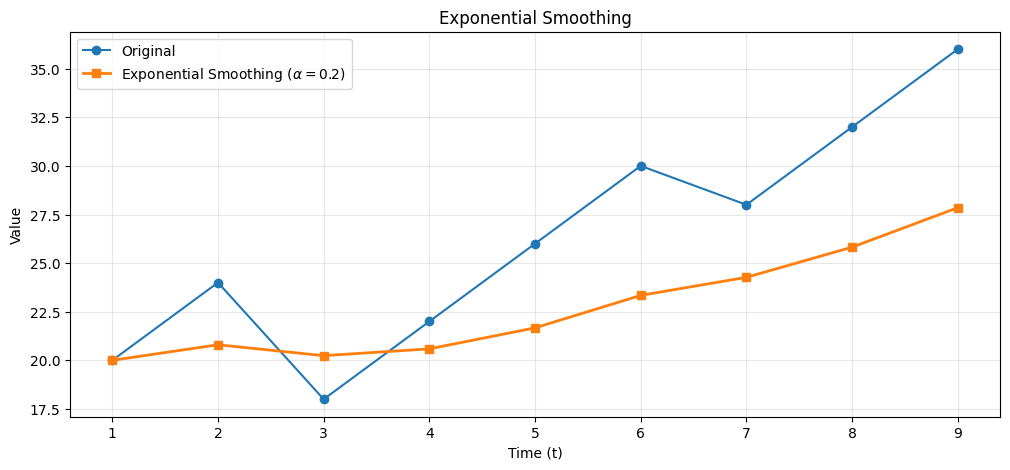

In [25]:
x = np.arange(1, len(data) + 1)

plt.figure(figsize=(12,5))
plt.plot(x, data, marker='o', label="Original")
plt.plot(x, es, marker='s', label=f"Exponential Smoothing ($\\alpha={alpha}$)", linewidth=2)

plt.xlabel("Time (t)")
plt.ylabel("Value")
plt.legend()
plt.title("Exponential Smoothing")
plt.grid(alpha=0.3)

plt.show()

## Nifty50

### Moving Average

[*********************100%***********************]  1 of 1 completed


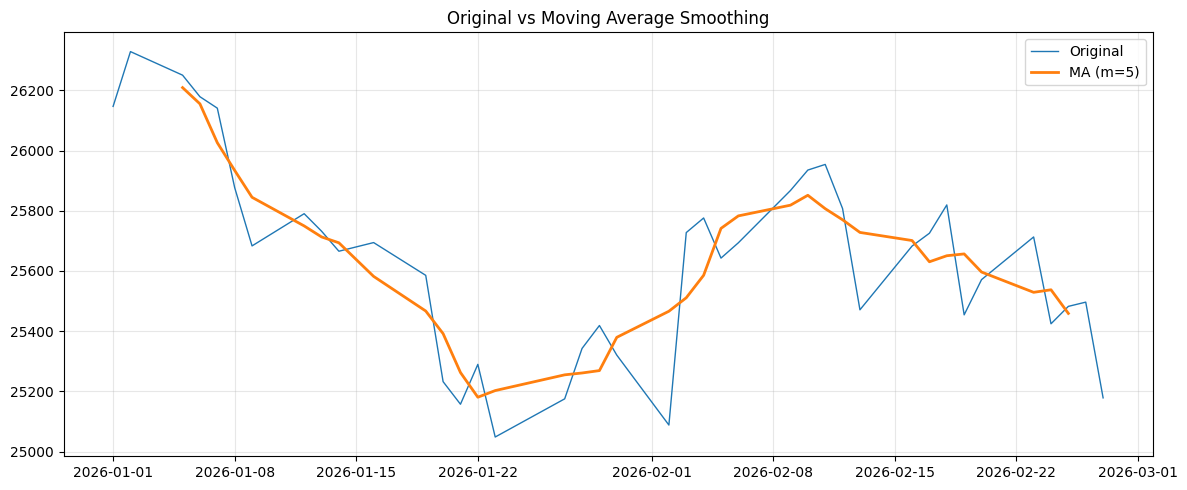

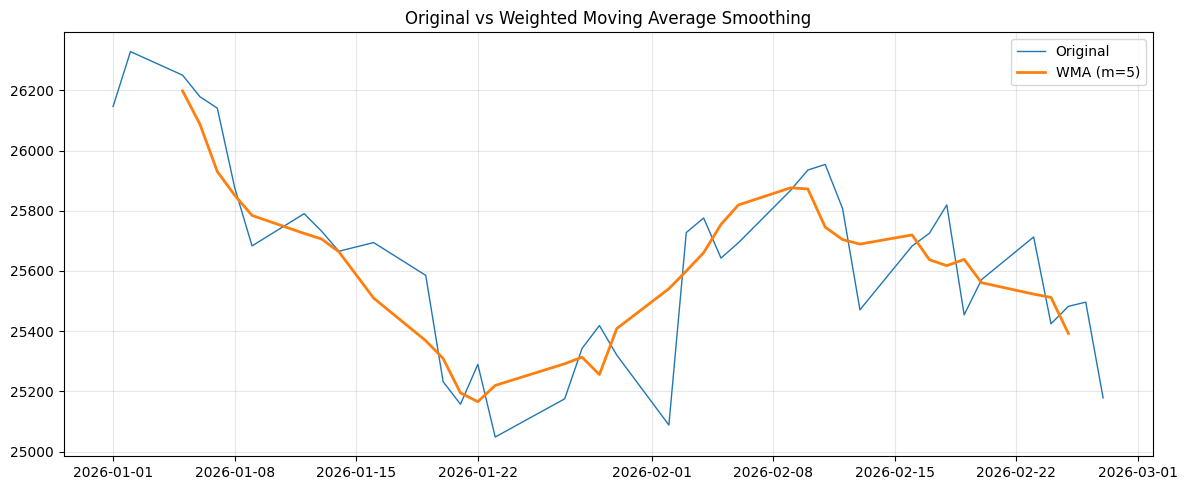

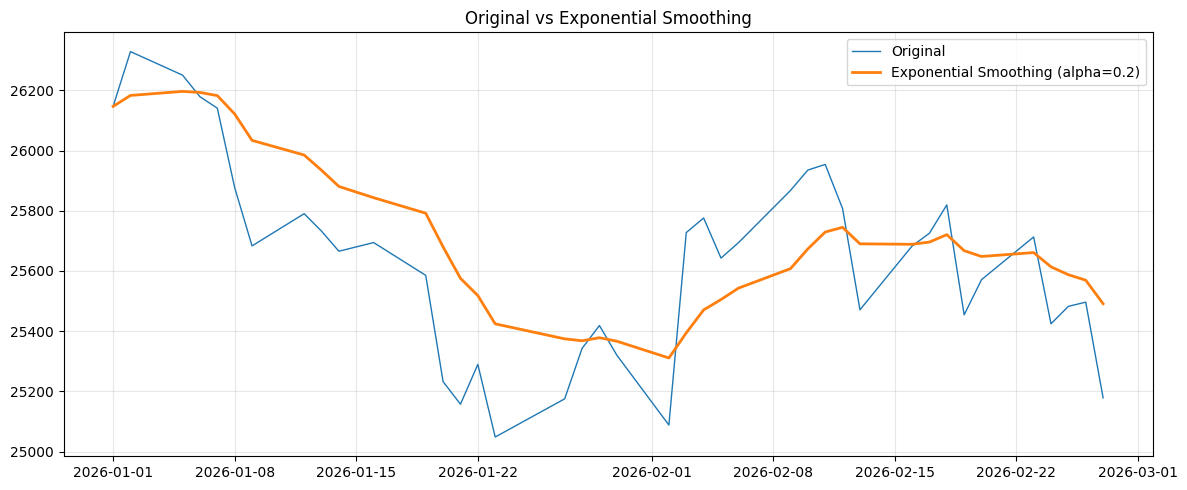

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Download data
df = yf.download("^NSEI", start="2026-01-01", end="2026-03-01")

m = 5

# Prepare data
data = df["Close"].dropna().to_numpy().squeeze()
dates = df.index

def moving_average(data, m):
    data = np.asarray(data).ravel()
    return np.convolve(data, np.ones(m)/m, mode='valid')

ma_n = moving_average(data, m)

# Align dates
dates_ma = dates[(m//2):-(m//2)]

plt.figure(figsize=(12,5))

# 1️⃣ Overlay
plt.plot(dates, data, label="Original", linewidth=1)
plt.plot(dates_ma, ma_n, label=f"MA (m={m})", linewidth=2)
plt.title("Original vs Moving Average Smoothing")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



###############

# Parameters
m = 5
weights = np.arange(1, m+1)  # [1,2,3,4,5] → more weight to recent

# Prepare data
data = df["Close"].dropna().to_numpy().squeeze()
dates = df.index

# WMA function
def weighted_moving_average(data, weights):
    data = np.asarray(data).ravel()
    m = len(weights)
    wma = []
    
    for i in range(len(data) - m + 1):
        window = data[i:i+m]
        value = np.sum(window * weights) / np.sum(weights)
        wma.append(value)
    
    return np.array(wma)

# Compute WMA
wma_n = weighted_moving_average(data, weights)

# Align dates
dates_wma = dates[(m//2):-(m//2)]

plt.figure(figsize=(12,5))

plt.plot(dates, data, label="Original", linewidth=1)
plt.plot(dates_wma, wma_n, label=f"WMA (m={m})", linewidth=2)
plt.title("Original vs Weighted Moving Average Smoothing")
plt.legend()
plt.grid(alpha=0.3)


plt.tight_layout()
plt.show()

###############




# Parameter
alpha = 0.2

# Prepare data
data = df["Close"].dropna().to_numpy().squeeze()
dates = df.index

# Exponential smoothing function
def exponential_smoothing(data, alpha):
    data = np.asarray(data).ravel()
    smoothed = [data[0]]
    
    for t in range(1, len(data)):
        s_t = alpha * data[t] + (1 - alpha) * smoothed[t - 1]
        smoothed.append(s_t)
    
    return np.array(smoothed)

# Compute ES
es = exponential_smoothing(data, alpha)

plt.figure(figsize=(12,5))

# 1) Overlay
plt.plot(dates, data, label="Original", linewidth=1)
plt.plot(dates, es, label=f"Exponential Smoothing (alpha={alpha})", linewidth=2)
plt.title("Original vs Exponential Smoothing")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

